# TP5 AA1 Clasificación

**Nicolás Druetta - DNI: 36604286.**

## Indicaciones básicas

1) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

2) Cada uno debe completar las consignas indicadas en este notebook.

3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial.

7) Revise las fecha límite de entrega de este trabajo.

# ENTREGA

**LEA LAS INDICACIONES DE ENTREGA EN EL FORO DE LA TAREA**

##**Tarea: Entrenamiento y evaluación de clasificadores**  

**Objetivo**: Aplicar un modelo de clasificación a un dataset de su elección, procesar dicho dataset para poder usarlo para entrenamiento, indicar y compartir todos los recursos utilizados, evaluar su rendimiento.
<br><br>

---

# INSTRUCCIONES

##1.&nbsp;**Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
   - Requisitos:  
     - Debe tener al menos 4 variables.
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.
<br>

---

### Resolución:

In [1]:
try:
    import ucimlrepo
except ModuleNotFoundError:
    !pip install ucimlrepo

*Verifico si la librería ucimlrepo está disponible y, si no está instalada, la instalo para poder descargar datasets desde UCI Machine Learning Repository.*

In [2]:
# Importo librerías necesarias.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Importo herramientas de clasificación.
from IPython.display import Markdown, display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from ucimlrepo import fetch_ucirepo

*Importo las librerías necesarias para manejar datos, graficar, cargar el dataset desde UCI, dividir los datos, estandarizar variables, entrenar modelos clasificadores y calcular métricas de evaluación.*

In [3]:
# Cargo el dataset Istanbul Stock Exchange desde UCI.
# https://archive.ics.uci.edu/dataset/247/istanbul+stock+exchange
istanbul_stock_exchange = fetch_ucirepo(id=247)

# Copio las variables del dataset.
df = istanbul_stock_exchange.data.features.copy()

# Muestro las primeras filas.
display(df.head())
print()

# Muestro la dimensión del dataset.
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print()

# Muestro los nombres originales de las columnas.
print(df.columns)

,date,ISE,ISE,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM
0,5-Jan-09,0.035754,0.035754,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524
1,6-Jan-09,0.025426,0.025426,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773
2,7-Jan-09,-0.028862,-0.028862,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
3,8-Jan-09,-0.062208,-0.062208,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424
4,9-Jan-09,0.009860,0.009860,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802



Filas: 536
Columnas: 10

Index(['date', 'ISE', 'ISE', 'SP', 'DAX', 'FTSE', 'NIKKEI', 'BOVESPA', 'EU',
       'EM'],
      dtype='object')


*Cargo el dataset Istanbul Stock Exchange desde UCI, copio sus variables en un DataFrame y muestro las primeras filas, la cantidad de filas y columnas, y los nombres originales de las columnas.*

Las variables financieras son:

  * **ISE**: Istanbul Stock Exchange National 100 Index (mercado bursátil de Turquía).
  * **SP**: S&P 500 Index (mercado bursátil de Estados Unidos).
  * **DAX**: Deutscher Aktienindex (mercado bursátil de Alemania).
  * **FTSE**: FTSE 100 Index (mercado bursátil del Reino Unido).
  * **NIKKEI**: Nikkei 225 Index (mercado bursátil de Japón).
  * **BOVESPA**: Bovespa Index (mercado bursátil de Brasil).
  * **EU**: MSCI Europe Index (mercados europeos desarrollados).
  * **EM**: MSCI Emerging Markets Index (mercados emergentes).

In [4]:
# Elimino columnas duplicadas para evitar problemas en el procesamiento.
df = df.loc[:, ~df.columns.duplicated()].copy()

# Creo una variable objetivo binaria.
# Target = 1 si el retorno de ISE fue positivo.
# Target = 0 si el retorno de ISE fue negativo o cero.
df["Target"] = (df["ISE"] > 0).astype(int)

# Muestro las primeras filas con la variable objetivo.
display(df.head())

,date,ISE,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM,Target
0,5-Jan-09,0.035754,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524,1
1,6-Jan-09,0.025426,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773,1
2,7-Jan-09,-0.028862,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015,0
3,8-Jan-09,-0.062208,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424,0
4,9-Jan-09,0.009860,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802,1


*Elimino columnas duplicadas y construyo la variable objetivo binaria Target, que vale 1 cuando el retorno de ISE es positivo y 0 cuando el retorno de ISE es negativo o igual a cero.*

Con **Target** paso el problema a clasificación binaria. No busco predecir el valor exacto de **ISE**, busco separar si el índice subió o no.

La clase **1** representa un retorno positivo y la clase **0** representa un retorno negativo o igual a cero. Con eso ya puedo entrenar mi modelo de clasificación.

##2.&nbsp;**Análisis exploratorio y preprocesamiento**

Realice una exploración inicial del dataset. Revise tipos de datos, valores faltantes, distribución de clases y prepare los datos para entrenamiento.
<br><br>

---

### Resolución:

In [5]:
# Armo una tabla resumen del dataset.
summary_df = pd.DataFrame({
    "Tipo de dato": df.dtypes,
    "Valores faltantes": df.isnull().sum(),
    "Valores únicos": df.nunique()
})

# Muestro el resumen general del dataset.
display(summary_df)

,Tipo de dato,Valores faltantes,Valores únicos
date,object,0,536
ISE,float64,0,536
SP,float64,0,519
DAX,float64,0,527
FTSE,float64,0,523
NIKKEI,float64,0,503
BOVESPA,float64,0,508
EU,float64,0,532
EM,float64,0,536
Target,int64,0,2


*Reviso el tipo de dato de cada columna, la cantidad de valores faltantes y la cantidad de valores únicos para detectar posibles problemas antes de entrenar el modelo.*

El resumen me permite revisar rápido cómo está armado el dataset. En este caso, las variables principales son numéricas y no aparecen valores faltantes, así que puedo seguir sin imputar datos.

In [6]:
# Calculo la distribución de la variable objetivo.
target_distribution_df = pd.DataFrame({
    "Cantidad": df["Target"].value_counts().sort_index(),
    "Porcentaje": df["Target"].value_counts(normalize=True).sort_index() * 100
})

# Redondeo el porcentaje para facilitar la lectura.
target_distribution_df["Porcentaje"] = target_distribution_df["Porcentaje"].round(2)

# Muestro la distribución de clases.
display(target_distribution_df)

,Cantidad,Porcentaje
Target,,
0,230,42.91
1,306,57.09


*Calculo cuántos casos hay en cada clase de Target y qué porcentaje representa cada una para evaluar si el dataset está balanceado o desbalanceado.*

La distribución de clases me muestra si un grupo tiene muchos más casos que el otro. Acá no están iguales, pero tampoco hay una diferencia muy grande.

Continúo con el modelo básico porque las clases están relativamente equilibradas.

In [7]:
# Defino las columnas predictoras.
feature_columns = ["SP", "DAX", "FTSE", "NIKKEI", "BOVESPA", "EU", "EM"]

# Defino variables predictoras y variable objetivo.
X = df[feature_columns].copy()
y = df["Target"].copy()

# Muestro las primeras filas de las variables predictoras.
display(X.head())
print()

# Muestro las primeras filas de la variable objetivo.
display(y.head())

,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM
0,-0.004679,0.002193,0.003894,0.000000,0.031190,0.012698,0.028524
1,0.007787,0.008455,0.012866,0.004162,0.018920,0.011341,0.008773
2,-0.030469,-0.017833,-0.028735,0.017293,-0.035899,-0.017073,-0.020015
3,0.003391,-0.011726,-0.000466,-0.040061,0.028283,-0.005561,-0.019424
4,-0.021533,-0.019873,-0.012710,-0.004474,-0.009764,-0.010989,-0.007802


,Target
0,1
1,1
2,0
3,0
4,1


*Separo las variables predictoras en X y la variable objetivo en y, dejando afuera la fecha y usando como entrada los retornos de los otros índices bursátiles.*

Con **X** dejo las variables que el modelo va a usar para aprender, y con **y** dejo la clase que tiene que predecir.

No uso **date** porque es una fecha. Tampoco uso **ISE** como predictora, porque de esa columna salió **Target**.

##3.&nbsp;**División en entrenamiento y testeo**

Separe el dataset en conjuntos de entrenamiento y testeo. Prepare los datos para poder entrenar modelos de clasificación.
<br><br>

---

### Resolución:

In [8]:
# Divido los datos en entrenamiento y testeo.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Mantengo la proporción de clases.
)

# Creo el estandarizador.
scaler = StandardScaler()

# Ajusto el estandarizador con entrenamiento y transformo ambos conjuntos.
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# Convierto los arreglos estandarizados nuevamente a DataFrame.
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=feature_columns, index=X_test.index)

# Muestro las dimensiones de los conjuntos generados.
print("Filas de entrenamiento:", X_train.shape[0])
print("Filas de testeo:", X_test.shape[0])
print("Columnas predictoras:", X_train.shape[1])
print()

# Muestro la distribución de clases en entrenamiento y testeo.
split_distribution_df = pd.DataFrame({
    "Entrenamiento": y_train.value_counts(normalize=True).sort_index() * 100,
    "Testeo": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

display(split_distribution_df)
print()

# Muestro las primeras filas estandarizadas.
display(X_train_scaled.head())

Filas de entrenamiento: 428
Filas de testeo: 108
Columnas predictoras: 7



,Entrenamiento,Testeo
Target,,
0,42.99,42.59
1,57.01,57.41


,SP,DAX,FTSE,NIKKEI,BOVESPA,EU,EM
96,-0.153871,0.224765,0.347120,-0.280252,0.544010,-0.074281,0.131840
45,-0.747343,0.451084,0.249754,-0.814021,-0.663931,-0.025915,-0.597404
320,0.071960,-0.018326,0.079424,0.274519,-0.754084,0.164046,-0.561437
53,-0.954246,0.779658,0.235144,-0.223734,0.429547,0.525815,0.863811
228,-0.026475,0.031263,0.214272,0.247720,0.011996,0.207412,0.497527


*Divido los datos en entrenamiento y testeo usando estratificación, estandarizo las variables predictoras y muestro las dimensiones y la distribución de clases de cada conjunto.*

Divido los datos para entrenar con una parte y evaluar con otra. Así puedo ver cómo responde el modelo con datos que no vio antes.

Uso estratificación; cuando separo entrenamiento y testeo, mantengo una proporción parecida de clases en los dos conjuntos. También estandarizo las variables para que queden en escalas comparables.

## 4.&nbsp;**Clasificación con logistic regression**

En este apartado entrenará un clasificador con la librería sklearn usando logistic regresion.
<br><br>

---

### Resolución:

### 4.1 Entrenamiento y evaluación

In [9]:
# Creo el modelo de regresión logística.
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Entreno el modelo con los datos de entrenamiento estandarizados.
logistic_model.fit(X_train_scaled, y_train)

# Genero predicciones para entrenamiento y testeo.
y_train_pred_logistic = logistic_model.predict(X_train_scaled)
y_test_pred_logistic = logistic_model.predict(X_test_scaled)

# Muestro valores principales del entrenamiento.
print("Modelo entrenado:", "Regresión Logística")
print()
print("Registros de entrenamiento:", X_train_scaled.shape[0])
print("Registros de testeo:", X_test_scaled.shape[0])
print("Variables predictoras utilizadas:", X_train_scaled.shape[1])
print("Clases del modelo:", logistic_model.classes_)
print("Iteraciones realizadas:", logistic_model.n_iter_[0])
print()

print("Intercepto:", f"{logistic_model.intercept_[0]:.2f}")
print()

# Muestro los coeficientes del modelo ordenados de mayor a menor.
print("Coeficientes del modelo ordenados de mayor a menor:")
for feature_name, coefficient in sorted(zip(X_train_scaled.columns, logistic_model.coef_[0]), key=lambda x: x[1], reverse=True):
    print(feature_name + ":", f"{coefficient:.2f}")

Modelo entrenado: Regresión Logística

Registros de entrenamiento: 428
Registros de testeo: 108
Variables predictoras utilizadas: 7
Clases del modelo: [0 1]
Iteraciones realizadas: 15

Intercepto: 0.40

Coeficientes del modelo ordenados de mayor a menor:
EM: 0.83
FTSE: 0.72
EU: 0.54
SP: 0.18
NIKKEI: -0.08
DAX: -0.09
BOVESPA: -0.20


*Creo y entreno un modelo de regresión logística, genero predicciones para entrenamiento y testeo, y muestro información del entrenamiento junto con los coeficientes aprendidos por el modelo.*

Uso regresión logística porque tengo una clasificación binaria: **Target** puede ser **0** o **1**.

**Intercepto**:

Lo aprende la regresión logística durante el entrenamiento, junto con los coeficientes. Representa el valor base del modelo antes de sumar el efecto de las variables predictoras. En este caso, como las variables fueron estandarizadas, ese valor base corresponde al punto en el que las variables están alrededor de su promedio.

**Coeficientes**:

* **EM**, **FTSE** y **EU** son los coeficientes más altos, por eso son las variables que más ayudan al modelo a predecir la clase **1**.
* **BOVESPA** aparece con coeficiente negativo. Eso quiere decir que influye para el otro lado, hacia la clase **0**.
* **DAX** y **NIKKEI** también son negativos, pero tienen menos peso.

Las variables financieras son:

  * **ISE**: Istanbul Stock Exchange National 100 Index (mercado bursátil de Turquía).
  * **SP**: S&P 500 Index (mercado bursátil de Estados Unidos).
  * **DAX**: Deutscher Aktienindex (mercado bursátil de Alemania).
  * **FTSE**: FTSE 100 Index (mercado bursátil del Reino Unido).
  * **NIKKEI**: Nikkei 225 Index (mercado bursátil de Japón).
  * **BOVESPA**: Bovespa Index (mercado bursátil de Brasil).
  * **EU**: MSCI Europe Index (mercados europeos desarrollados).
  * **EM**: MSCI Emerging Markets Index (mercados emergentes).

### 4.2 Métricas de evaluación
Muestre el desempeño en el conjunto de datos de entrenamiento y testeo.
Mencione las métricas utilizadas. No se olvide de mostrar la matriz de confusión.
Explique los resultados obtenidos.
<br><br>

---

### Resolución:

In [10]:
# Función para mostrar métricas y matriz de confusión.
def mostrar_metricas_modelo(type, accuracy, precision, recall, f1, confusion_matrix):
    display(Markdown(f"### Métricas de {type}:"))
    display(Markdown("---"))

    display(Markdown(f"**Accuracy: {accuracy:.2f}.** (El modelo acierta el **{int(accuracy * 100)}%** de las predicciones en {type})."))
    display(Markdown(f"**Precisión: {precision:.2f}.** (El modelo acierta el **{int(precision * 100)}%** de las veces cuando predice clase **1**)."))
    display(Markdown(f"**Recall: {recall:.2f}.** (El modelo encuentra el **{int(recall * 100)}%** de todos los registros que realmente eran clase **1**)."))
    display(Markdown(f"**F1-score: {f1:.2f}.** (El equilibrio es de **{int(f1 * 100)}%** entre precisión y recall en {type})."))

    display(Markdown("**Matriz de confusión**:"))
    print(confusion_matrix)

    display(Markdown(f"* [**{confusion_matrix[0, 0]}** registros de clase **0** fueron clasificados como **0**] [**{confusion_matrix[0, 1]}** registros de clase **0** fueron clasificados como **1**]"))
    display(Markdown(f"* [**{confusion_matrix[1, 0]}** registros de clase **1** fueron clasificados como **0**] [**{confusion_matrix[1, 1]}** registros de clase **1** fueron clasificados como **1**]"))

In [11]:
# Calculo métricas para el conjunto de entrenamiento.
train_accuracy_logistic = round(accuracy_score(y_train, y_train_pred_logistic), 2)
train_precision_logistic = round(precision_score(y_train, y_train_pred_logistic, zero_division=0), 2)
train_recall_logistic = round(recall_score(y_train, y_train_pred_logistic, zero_division=0), 2)
train_f1_logistic = round(f1_score(y_train, y_train_pred_logistic, zero_division=0), 2)
train_confusion_matrix_logistic = confusion_matrix(y_train, y_train_pred_logistic)

# Calculo métricas para el conjunto de testeo.
test_accuracy_logistic = round(accuracy_score(y_test, y_test_pred_logistic), 2)
test_precision_logistic = round(precision_score(y_test, y_test_pred_logistic, zero_division=0), 2)
test_recall_logistic = round(recall_score(y_test, y_test_pred_logistic, zero_division=0), 2)
test_f1_logistic = round(f1_score(y_test, y_test_pred_logistic, zero_division=0), 2)
test_confusion_matrix_logistic = confusion_matrix(y_test, y_test_pred_logistic)

# Muestro las métricas del conjunto de entrenamiento.
mostrar_metricas_modelo("entrenamiento (LR)", train_accuracy_logistic, train_precision_logistic, train_recall_logistic, train_f1_logistic, train_confusion_matrix_logistic)
print()

# Muestro las métricas del conjunto de testeo.
mostrar_metricas_modelo("testeo (LR)", test_accuracy_logistic, test_precision_logistic, test_recall_logistic, test_f1_logistic, test_confusion_matrix_logistic)

### Métricas de entrenamiento (LR):

---

**Accuracy: 0.73.** (El modelo acierta el **73%** de las predicciones en entrenamiento (LR)).

**Precisión: 0.74.** (El modelo acierta el **74%** de las veces cuando predice clase **1**).

**Recall: 0.80.** (El modelo encuentra el **80%** de todos los registros que realmente eran clase **1**).

...

**F1-score: 0.78.** (El equilibrio es de **78%** entre precisión y recall en testeo (LR)).

**Matriz de confusión**:

[[26 20]
 [10 52]]


* [**26** registros de clase **0** fueron clasificados como **0**] [**20** registros de clase **0** fueron clasificados como **1**]

* [**10** registros de clase **1** fueron clasificados como **0**] [**52** registros de clase **1** fueron clasificados como **1**]

*Calculo accuracy, precision, recall, F1-score y matriz de confusión para entrenamiento y testeo, y luego muestro esos resultados para evaluar el rendimiento del modelo.*

> 🙂 Me quedó hermosa la salida de las métricas. Se entiende perfecto.

## 5.&nbsp;**Otro clasificador**

### 5.1 Elija otro modelo para entrenar un clasificador

Elija alguno de los modelos vistos: kNN, SVM o MLP para entrenar un clasificador usando los parámetros por defecto de sklearn.

Justifique su elección.
<br><br>

---

>Elijo **kNN** porque es un modelo simple y visto en la materia. La idea es clasificar cada registro según los vecinos más cercanos.
>
>Como las variables ya están estandarizadas, tiene sentido usarlo, porque kNN depende de distancias entre registros.

### 5.2 Entrenamiento del modelo.

In [12]:
# Creo el modelo kNN con los parámetros por defecto de sklearn.
knn_model = KNeighborsClassifier()

# Entreno el modelo kNN con los datos de entrenamiento estandarizados.
knn_model.fit(X_train_scaled, y_train)

# Genero predicciones para entrenamiento y testeo.
y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn = knn_model.predict(X_test_scaled)

# Muestro valores principales del entrenamiento.
print("Modelo entrenado:", "k vecinos más cercanos")
print()
print("Registros de entrenamiento:", X_train_scaled.shape[0])
print("Registros de testeo:", X_test_scaled.shape[0])
print("Variables predictoras utilizadas:", X_train_scaled.shape[1])
print("Clases del modelo:", knn_model.classes_)
print()

# Muestro los parámetros principales del modelo.
print("Parámetros principales del modelo:")
print("Cantidad de vecinos utilizada:", knn_model.n_neighbors)
print("Tipo de pesos:", knn_model.weights)
print("Métrica de distancia:", knn_model.metric)
print("Algoritmo utilizado:", knn_model.algorithm)
print("Potencia de Minkowski:", knn_model.p)

Modelo entrenado: k vecinos más cercanos

Registros de entrenamiento: 428
Registros de testeo: 108
Variables predictoras utilizadas: 7
Clases del modelo: [0 1]

Parámetros principales del modelo:
Cantidad de vecinos utilizada: 5
Tipo de pesos: uniform
Métrica de distancia: minkowski
Algoritmo utilizado: auto
Potencia de Minkowski: 2


*Creo un modelo kNN, lo entreno con los datos estandarizados y genero predicciones para entrenamiento y testeo.*

Entreno un modelo kNN con los datos estandarizados para que las variables queden en escalas parecidas. Uso la cantidad de vecinos por defecto para tener una primera referencia del rendimiento del modelo.

### 5.3 Evaluación del desempeño

In [13]:
# Calculo métricas para el conjunto de entrenamiento.
train_accuracy_knn = round(accuracy_score(y_train, y_train_pred_knn), 2)
train_precision_knn = round(precision_score(y_train, y_train_pred_knn, zero_division=0), 2)
train_recall_knn = round(recall_score(y_train, y_train_pred_knn, zero_division=0), 2)
train_f1_knn = round(f1_score(y_train, y_train_pred_knn, zero_division=0), 2)
train_confusion_matrix_knn = confusion_matrix(y_train, y_train_pred_knn)

# Calculo métricas para el conjunto de testeo.
test_accuracy_knn = round(accuracy_score(y_test, y_test_pred_knn), 2)
test_precision_knn = round(precision_score(y_test, y_test_pred_knn, zero_division=0), 2)
test_recall_knn = round(recall_score(y_test, y_test_pred_knn, zero_division=0), 2)
test_f1_knn = round(f1_score(y_test, y_test_pred_knn, zero_division=0), 2)
test_confusion_matrix_knn = confusion_matrix(y_test, y_test_pred_knn)

# Muestro las métricas del conjunto de entrenamiento.
mostrar_metricas_modelo("entrenamiento (kNN)", train_accuracy_knn, train_precision_knn, train_recall_knn, train_f1_knn, train_confusion_matrix_knn)
print()

# Muestro las métricas del conjunto de testeo.
mostrar_metricas_modelo("testeo (kNN)", test_accuracy_knn, test_precision_knn, test_recall_knn, test_f1_knn, test_confusion_matrix_knn)

### Métricas de entrenamiento (kNN):

---

**Accuracy: 0.79.** (El modelo acierta el **79%** de las predicciones en entrenamiento (kNN)).

**Precisión: 0.81.** (El modelo acierta el **81%** de las veces cuando predice clase **1**).

**Recall: 0.81.** (El modelo encuentra el **81%** de todos los registros que realmente eran clase **1**).

...

**F1-score: 0.73.** (El equilibrio es de **73%** entre precisión y recall en testeo (kNN)).

**Matriz de confusión**:

[[28 18]
 [16 46]]


* [**28** registros de clase **0** fueron clasificados como **0**] [**18** registros de clase **0** fueron clasificados como **1**]

* [**16** registros de clase **1** fueron clasificados como **0**] [**46** registros de clase **1** fueron clasificados como **1**]

*Calculo las métricas principales y las matrices de confusión para el modelo kNN, tanto en entrenamiento como en testeo.*

> 📊 Me da mejor la Regresión Logística que el kNN.

## 6.&nbsp;Tuneo de hiperparámetros

En esta sección debe modificar probar cómo la modificación de un hiperparámetro del modelo elegido en punto 5) afecta en los resultados.

Justifique y realice el experimento en esta sección.
<br><br>

---

### Resolución:

Para el tuneo cambio **n_neighbors**, que es la cantidad de vecinos que usa kNN para decidir la clase.

Pruebo varios valores para ver si el modelo mejora cuando uso más o menos vecinos.

In [14]:
# Defino los valores de vecinos que voy a probar.
neighbors_values = [1, 3, 5, 7, 9, 11, 15]

# Creo una lista para guardar los resultados.
tuning_results = []

# Entreno y evalúo un modelo kNN para cada valor de vecinos.
for neighbors in neighbors_values:
    tuned_knn_model = KNeighborsClassifier(n_neighbors=neighbors)
    tuned_knn_model.fit(X_train_scaled, y_train)

    y_train_pred_tuned_knn = tuned_knn_model.predict(X_train_scaled)
    y_test_pred_tuned_knn = tuned_knn_model.predict(X_test_scaled)

    tuning_results.append({
        "Vecinos": neighbors,
        "Accuracy entrenamiento": accuracy_score(y_train, y_train_pred_tuned_knn),
        "Accuracy testeo": accuracy_score(y_test, y_test_pred_tuned_knn),
        "Precisión testeo": precision_score(y_test, y_test_pred_tuned_knn, zero_division=0),
        "Recall testeo": recall_score(y_test, y_test_pred_tuned_knn, zero_division=0),
        "F1-score testeo": f1_score(y_test, y_test_pred_tuned_knn, zero_division=0)
    })

# Convierto los resultados a DataFrame.
tuning_results_df = pd.DataFrame(tuning_results)

# Redondeo los valores para facilitar la lectura.
tuning_results_df = tuning_results_df.round(2)

# Muestro la tabla comparativa.
display(tuning_results_df)
print()

# Selecciono el mejor modelo según F1-score de testeo.
best_neighbors = tuning_results_df.sort_values(by="F1-score testeo", ascending=False).iloc[0]["Vecinos"]

# Muestro el mejor k para este modelo.
display(Markdown(f"**El mejor valor de k para este modelo es {int(best_neighbors)}, según el F1-score de testeo.**"))

,Vecinos,Accuracy entrenamiento,Accuracy testeo,Precisión testeo,Recall testeo,F1-score testeo
0,1,1.00,0.62,0.67,0.68,0.67
1,3,0.83,0.64,0.67,0.73,0.70
2,5,0.79,0.69,0.72,0.74,0.73
3,7,0.78,0.71,0.73,0.79,0.76
4,9,0.78,0.68,0.70,0.77,0.73
5,11,0.76,0.70,0.72,0.79,0.75
6,15,0.75,0.69,0.70,0.81,0.75


**El mejor valor de k para este modelo es 7, según el F1-score de testeo.**

*Pruebo distintos valores de vecinos para kNN, entreno un modelo con cada valor, calculo métricas de evaluación y selecciono el mejor resultado según F1-score en testeo.*

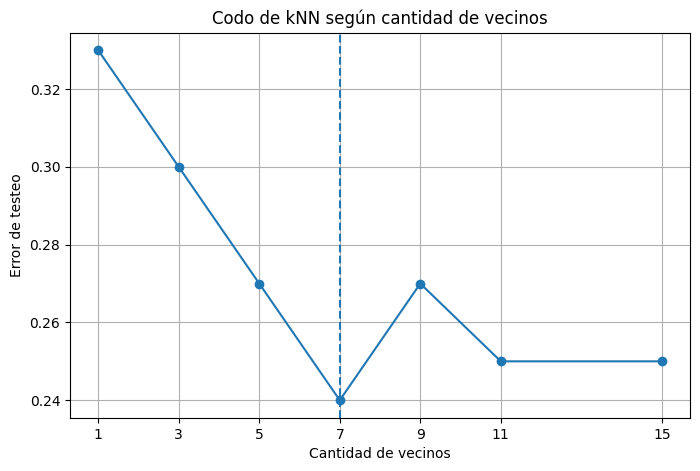

In [15]:
# Calculo el error de testeo para graficar el codo.
tuning_plot_df = tuning_results_df.copy()
tuning_plot_df["Error testeo"] = 1 - tuning_plot_df["F1-score testeo"]

# Grafico el error según la cantidad de vecinos.
plt.figure(figsize=(8, 5))
plt.plot(tuning_plot_df["Vecinos"], tuning_plot_df["Error testeo"], marker="o")
plt.axvline(x=best_neighbors, linestyle="--")
plt.title("Codo de kNN según cantidad de vecinos")
plt.xlabel("Cantidad de vecinos")
plt.ylabel("Error de testeo")
plt.xticks(tuning_plot_df["Vecinos"])
plt.grid(True)
plt.show()

*Grafico el error de testeo según la cantidad de vecinos para ver visualmente qué valor de k conviene más.*

In [16]:
# Entreno el mejor kNN encontrado en el tuneo.
best_knn_model = KNeighborsClassifier(n_neighbors=int(best_neighbors))
best_knn_model.fit(X_train_scaled, y_train)

# Genero predicciones con el mejor kNN.
y_test_pred_best_knn = best_knn_model.predict(X_test_scaled)

# Calculo métricas del mejor kNN.
test_accuracy_best_knn = round(accuracy_score(y_test, y_test_pred_best_knn), 2)
test_precision_best_knn = round(precision_score(y_test, y_test_pred_best_knn, zero_division=0), 2)
test_recall_best_knn = round(recall_score(y_test, y_test_pred_best_knn, zero_division=0), 2)
test_f1_best_knn = round(f1_score(y_test, y_test_pred_best_knn, zero_division=0), 2)

*Entreno el modelo con el mejor kNN encontrado*

Me quedo con **7 vecinos** porque fue el valor que mejor resultado me dio en el tuneo, mirando el **F1-score de testeo**. Así que no uso kNN con el valor por defecto y elijo el que mejor funcionó en mis pruebas.

## 7.&nbsp;Conclusiones

Fundamente, justifique con sus palabras.
<br><br>

---

### Resolución:

In [17]:
# Tomo la mejor fila del tuneo según F1-score de testeo.
best_tuning_result = tuning_results_df.sort_values(by="F1-score testeo", ascending=False).iloc[0]

# Armo una tabla resumen incluyendo el kNN tuneado.
models_summary_with_tuning_df = pd.DataFrame({
    "Modelo": ["Regresión logística", "kNN por defecto", "kNN tuneado"],
    "Accuracy testeo": [
        test_accuracy_logistic,
        test_accuracy_knn,
        best_tuning_result["Accuracy testeo"]
    ],
    "Precisión testeo": [
        test_precision_logistic,
        test_precision_knn,
        best_tuning_result["Precisión testeo"]
    ],
    "Recall testeo": [
        test_recall_logistic,
        test_recall_knn,
        best_tuning_result["Recall testeo"]
    ],
    "F1-score testeo": [
        test_f1_logistic,
        test_f1_knn,
        best_tuning_result["F1-score testeo"]
    ]
}).round(2)

# Muestro la comparación final ampliada.
display(models_summary_with_tuning_df)
print()

# Selecciono el mejor modelo según F1-score de testeo.
best_model_result = models_summary_with_tuning_df.sort_values(by="F1-score testeo", ascending=False).iloc[0]

# Muestro el mejor modelo y su F1-score.
display(Markdown(f"**Mejor modelo: {best_model_result['Modelo']}. F1-score: {best_model_result['F1-score testeo']:.2f}.**"))

,Modelo,Accuracy testeo,Precisión testeo,Recall testeo,F1-score testeo
0,Regresión logística,0.72,0.72,0.84,0.78
1,kNN por defecto,0.69,0.72,0.74,0.73
2,kNN tuneado,0.71,0.73,0.79,0.76


**Mejor modelo: Regresión logística. F1-score: 0.78.**

*Armo una tabla resumen para comparar la regresión logística, kNN por defecto y kNN tuneado usando las métricas obtenidas en el conjunto de testeo.*

Con esta comparación puedo ver qué modelo funciona mejor en testeo.

La regresión logística fue el modelo que mejor resultado general me dio. En especial, tuvo mejor **F1-score de testeo**, que es la métrica que más me sirve para mirar el equilibrio entre precision y recall.

kNN por defecto quedó un poco más abajo. Después del tuneo mejoró, y el mejor valor fue **7 vecinos**, pero aun así no superó a la regresión logística.

Por eso, para este trabajo me quedo con la **regresión logística** como modelo principal. Es un modelo simple, estable y con mejor comportamiento en testeo para este dataset.

# Referencias

- UCI Machine Learning Repository. Istanbul Stock Exchange dataset: https://archive.ics.uci.edu/dataset/247/istanbul+stock+exchange
- Documentación oficial de scikit-learn: https://scikit-learn.org/stable/
- Documentación de pandas: https://pandas.pydata.org/docs/
- Documentación de NumPy: https://numpy.org/doc/
- Apuntes y material de clase de Aprendizaje Automático I.
- ChatGPT como asistente para dudas y consultas.

# BONUS 1

Si su dataset estaba relativamente balanceado, como bonus pruebe entrenar otro modelo clasificador diferente y comparar resultados con su clasificador elegido en 5) y el modelo elegido 6) luego del tuneo de hiperparámetros.
<br><br>

---

### Resolución:

In [18]:
# Creo el modelo SVM con los parámetros por defecto de sklearn.
svm_model = SVC(random_state=42)

# Entreno el modelo SVM con los datos de entrenamiento estandarizados.
svm_model.fit(X_train_scaled, y_train)

# Genero predicciones para entrenamiento y testeo.
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)

# Muestro valores principales del entrenamiento.
print("Modelo entrenado:", "SVM")
print()
print("Registros de entrenamiento:", X_train_scaled.shape[0])
print("Registros de testeo:", X_test_scaled.shape[0])
print("Variables predictoras utilizadas:", X_train_scaled.shape[1])
print("Clases del modelo:", svm_model.classes_)
print()

# Muestro los parámetros principales del modelo.
print("Parámetros principales del modelo:")
print("Kernel utilizado:", svm_model.kernel)
print("Parámetro C:", svm_model.C)
print("Gamma:", svm_model.gamma)
print("Grado:", svm_model.degree)
print("Coeficiente independiente:", svm_model.coef0)

Modelo entrenado: SVM

Registros de entrenamiento: 428
Registros de testeo: 108
Variables predictoras utilizadas: 7
Clases del modelo: [0 1]

Parámetros principales del modelo:
Kernel utilizado: rbf
Parámetro C: 1.0
Gamma: scale
Grado: 3
Coeficiente independiente: 0.0


*Entreno un modelo SVM como clasificador adicional para el bonus. Uso los mismos datos escalados que ya venía usando con los otros modelos, así la comparación queda pareja.*

In [19]:
# Calculo métricas para el conjunto de entrenamiento.
train_accuracy_svm = round(accuracy_score(y_train, y_train_pred_svm), 2)
train_precision_svm = round(precision_score(y_train, y_train_pred_svm, zero_division=0), 2)
train_recall_svm = round(recall_score(y_train, y_train_pred_svm, zero_division=0), 2)
train_f1_svm = round(f1_score(y_train, y_train_pred_svm, zero_division=0), 2)
train_confusion_matrix_svm = confusion_matrix(y_train, y_train_pred_svm)

# Calculo métricas para el conjunto de testeo.
test_accuracy_svm = round(accuracy_score(y_test, y_test_pred_svm), 2)
test_precision_svm = round(precision_score(y_test, y_test_pred_svm, zero_division=0), 2)
test_recall_svm = round(recall_score(y_test, y_test_pred_svm, zero_division=0), 2)
test_f1_svm = round(f1_score(y_test, y_test_pred_svm, zero_division=0), 2)
test_confusion_matrix_svm = confusion_matrix(y_test, y_test_pred_svm)

# Muestro las métricas del conjunto de entrenamiento.
mostrar_metricas_modelo("entrenamiento (SVM)", train_accuracy_svm, train_precision_svm, train_recall_svm, train_f1_svm, train_confusion_matrix_svm)
print()

# Muestro las métricas del conjunto de testeo.
mostrar_metricas_modelo("testeo (SVM)", test_accuracy_svm, test_precision_svm, test_recall_svm, test_f1_svm, test_confusion_matrix_svm)

### Métricas de entrenamiento (SVM):

---

**Accuracy: 0.75.** (El modelo acierta el **75%** de las predicciones en entrenamiento (SVM)).

**Precisión: 0.75.** (El modelo acierta el **75%** de las veces cuando predice clase **1**).

**Recall: 0.84.** (El modelo encuentra el **84%** de todos los registros que realmente eran clase **1**).

...

**F1-score: 0.80.** (El equilibrio es de **80%** entre precisión y recall en testeo (SVM)).

**Matriz de confusión**:

[[25 21]
 [ 7 55]]


* [**25** registros de clase **0** fueron clasificados como **0**] [**21** registros de clase **0** fueron clasificados como **1**]

* [**7** registros de clase **1** fueron clasificados como **0**] [**55** registros de clase **1** fueron clasificados como **1**]

*Calculo las mismas métricas para entrenamiento y testeo: accuracy, precisión, recall y F1-score.*

El modelo SVM tuvo un buen resultado en testeo. En este caso, el **F1-score** fue el más alto de la comparación, por eso funciona como una buena alternativa para el bonus.

Igual, lo uso como modelo adicional. La comparación principal ya venía entre regresión logística y kNN, pero SVM sirve para ver si otro clasificador puede mejorar los resultados.

In [20]:
# Armo una tabla comparativa.
metrics_df = pd.DataFrame({
    "Modelo": [
        "Regresión logística",
        "kNN por defecto",
        "kNN tuneado",
        "SVM"
    ],
    "Accuracy testeo": [
        test_accuracy_logistic,
        test_accuracy_knn,
        test_accuracy_best_knn,
        test_accuracy_svm
    ],
    "Precisión testeo": [
        test_precision_logistic,
        test_precision_knn,
        test_precision_best_knn,
        test_precision_svm
    ],
    "Recall testeo": [
        test_recall_logistic,
        test_recall_knn,
        test_recall_best_knn,
        test_recall_svm
    ],
    "F1-score testeo": [
        test_f1_logistic,
        test_f1_knn,
        test_f1_best_knn,
        test_f1_svm
    ]
}).round(2)

# Muestro la comparación del bonus.
display(metrics_df)
print()

# Selecciono el mejor modelo según F1-score de testeo.
best_model_result = metrics_df.sort_values(by="F1-score testeo", ascending=False).iloc[0]

# Muestro el mejor modelo y su F1-score.
display(Markdown(f"**Mejor modelo: {best_model_result['Modelo']}. F1-score: {best_model_result['F1-score testeo']:.2f}.**"))

,Modelo,Accuracy testeo,Precisión testeo,Recall testeo,F1-score testeo
0,Regresión logística,0.72,0.72,0.84,0.78
1,kNN por defecto,0.69,0.72,0.74,0.73
2,kNN tuneado,0.71,0.73,0.79,0.76
3,SVM,0.74,0.72,0.89,0.80


**Mejor modelo: SVM. F1-score: 0.80.**

In [ ]:
# Grafico el F1-score de testeo de todos los modelos.
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_df["Modelo"], metrics_df["F1-score testeo"])

plt.title("Comparación de F1-score en testeo")
plt.xlabel("Modelo")
plt.ylabel("F1-score")

plt.ylim(0, 1)
plt.xticks(rotation=15)

# Muestro el valor de F1-score arriba de cada barra.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

*Grafico el F1-score de testeo para comparar el modelo SVM del bonus contra la regresión logística, kNN por defecto y kNN tuneado.*

Al comparar los modelos, **SVM es el que mejor resultado obtiene**, porque tiene el **F1-score de testeo más alto**. La regresión logística también funciona bien, pero queda un poco por debajo. kNN mejora con el tuneo, aunque no llega a superar a SVM.

Por eso, para el bonus, el mejor modelo probado es **SVM**.

# BONUS 2

Si su dataset estaba desbalanceado, puebe utilizar alguna técnica para lidiar con el desbalance de clases durante el entrenamiento.

1) Ofrezca una comparativa de entrenar y evaluar modelos de Logistic regression con y sin class_weight='balanced' o el modelo SVC con y sin class_weight='balanced'

2) Pruebe entrenar KNN con y sin uso de SMOTE

(Ver apunte sobre Desbalance de clases de la cátedra)
<br><br>

---

### Resolución:

No desarrollo este bonus porque el dataset no está desbalanceado.

La distribución de clases no es exactamente igual, pero tampoco hay una diferencia grande entre una clase y la otra. Por eso no corresponde aplicar técnicas de balanceo como **class_weight='balanced'** o **SMOTE** para este dataset.